# 凝聚型层次聚类

本实验使用与 K-means 实验相同的数据。主要观察Ward 凝聚法如何从单个样本出发，逐步合并为完整的层次树。

In [1]:
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import InlineBackend
import numpy as np
from scipy.cluster.hierarchy import dendrogram
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

plt.style.use("seaborn-v0_8-whitegrid")
InlineBackend.instance().print_figure_kwargs = {"bbox_inches": None}
SINGLE_FIGSIZE = (8, 5.5)

## 1. 生成并标准化数据

数据的样本量、中心、离散程度和随机种子均与 K-means 实验相同。

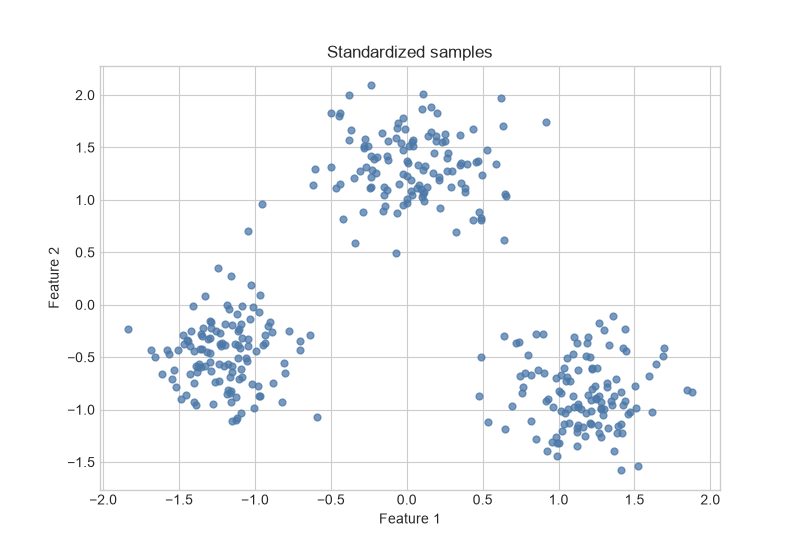

In [2]:
X, _ = make_blobs(
    n_samples=360,
    centers=[(-4, -1), (0, 4), (4, -2)],
    cluster_std=[0.85, 1.00, 0.90],
    random_state=42,
)
X_scaled = StandardScaler().fit_transform(X)

fig, ax = plt.subplots(figsize=SINGLE_FIGSIZE)
ax.scatter(X_scaled[:, 0], X_scaled[:, 1], s=24, alpha=0.75, color="#4C78A8")
ax.set(title="Standardized samples", xlabel="Feature 1", ylabel="Feature 2")
plt.show()

## 2. 展示逐步合并过程

树状图底部每个叶节点表示一个样本；每个分叉连接表示两个簇被合并；最上方只剩一个包含全部样本的簇。虚线是产生 $3$ 个簇的切割位置，虚线下方的不同颜色对应最终簇。

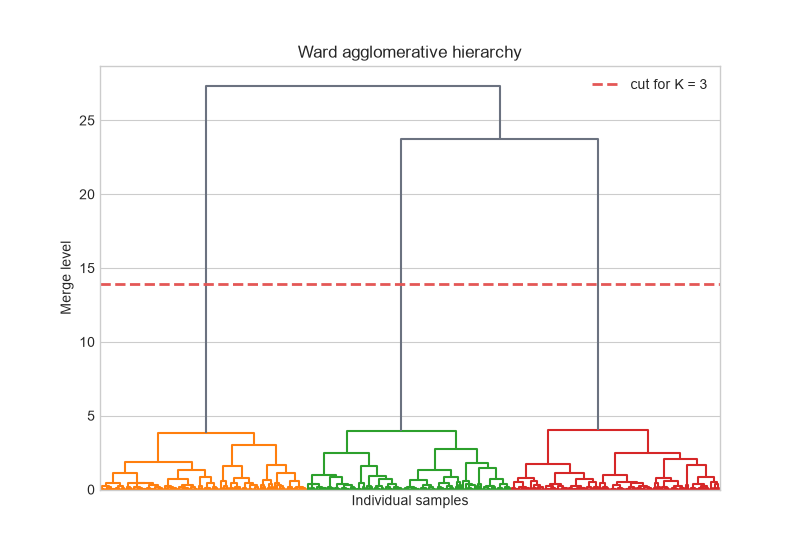

In [3]:
tree = AgglomerativeClustering(
    n_clusters=None,
    distance_threshold=0,
    linkage="ward",
    compute_distances=True,
).fit(X_scaled)

n_samples = X_scaled.shape[0]
cluster_sizes = np.zeros(len(tree.children_), dtype=int)
for step, (left, right) in enumerate(tree.children_):
    left_size = 1 if left < n_samples else cluster_sizes[left - n_samples]
    right_size = 1 if right < n_samples else cluster_sizes[right - n_samples]
    cluster_sizes[step] = left_size + right_size

linkage_matrix = np.column_stack(
    [tree.children_, tree.distances_, cluster_sizes]
).astype(float)

lower_height = tree.distances_[-3]
upper_height = tree.distances_[-3 + 1]
cut_height = (lower_height + upper_height) / 2

fig, ax = plt.subplots(figsize=SINGLE_FIGSIZE)
dendrogram(
    linkage_matrix,
    color_threshold=cut_height,
    above_threshold_color="#6B7280",
    no_labels=True,
    ax=ax,
)
ax.axhline(cut_height, color="#E45756", linestyle="--", linewidth=2, label="cut for K = 3")
ax.set(title="Ward agglomerative hierarchy", xlabel="Individual samples", ylabel="Merge level")
ax.legend()
plt.show()